# PREM: Love numbers and compliances of the real Earth

Notebooks 1–3 built everything on toy models — a single sphere, a static fluid, a mock three-layer
Earth. None of that machinery cared that the model was a toy: it applies unchanged to the *real*
radial Earth. `PREM()` loads the **Preliminary Reference Earth Model** (Dziewonski & Anderson 1981)
as an ordinary `PlanetModel` — solid inner core, fluid outer core, layered mantle and crust — and the
same `love_numbers` and `compliances` calls from the earlier notebooks return the tidal **Love
numbers** and the Sasao nutation **compliances**, which we check against accepted values.

In [8]:
using Pkg; Pkg.activate(@__DIR__)
using Melinoe, PyPlot, Printf

# PREM() is now the raw published model (tabulated κ, elastic). For the Love numbers we want a
# well-posed core, so opt into the Adams–Williamson closure (N² = 0); elastic is the default.
m = Melinoe.Models.PREM(use_aw_oc = false, ocean = false)
println(m)

  Activating project at `~/code/ge-julia/examples`


PlanetModel("PREM", 12 layers, R=6371.0 km, ρ̄=5515.0 kg/m³)


## 1 · The model

`PREM()` returns the **raw published model**: ten regions from centre to surface, PREM-tabulated κ,
elastic 1 s reference. Two modifications are opt-in, and this notebook uses each where it matches
published values:

- **Love numbers (§2)** want a *well-posed* core, so we opt into the **Adams–Williamson** outer core
  (`use_aw_oc = true`, `N² = 0`).
- **Compliances (§3)** are tabulated by Sasao/Mathews for the *tabulated* core, whose `N² ≠ 0` needs
  the Dahlen closure (NB2) — so `dahlenize(PREM())`.

Both stay **elastic** (`anelastic = false`, the default), since those tabulations skip dispersion;
`anelastic = true` is for tidal-band and free-mode work (NB5).

Density and gravity below; the shaded band is the **fluid outer core** (μ = 0), between the ICB
(1221.5 km) and the CMB (3480 km).

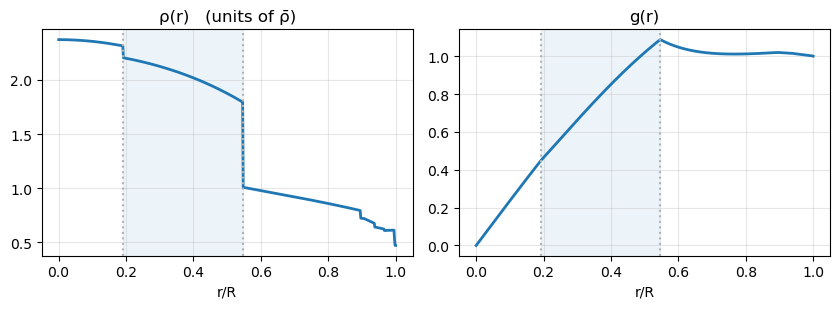

In [9]:
rr = range(1e-4, 1, length = 600)
ρ(r) = (for l in m.layers; r ≤ rightendpoint(l.domain)+1e-9 && return l.ρ₀(r); end)
g(r) = (for l in m.layers; r ≤ rightendpoint(l.domain)+1e-9 && return l.g₀(r); end)
r_ICB, r_CMB = 1221.5/6371, 3480/6371
fig, ax = subplots(1, 2, figsize = (8.5, 3.2))
ax[1].plot(rr, ρ.(rr), lw = 2); ax[1].set_title("ρ(r)   (units of ρ̄)")
ax[2].plot(rr, g.(rr), lw = 2); ax[2].set_title("g(r)")
for a in ax
    a.set_xlabel("r/R"); a.grid(alpha = 0.3)
    a.axvspan(r_ICB, r_CMB, color = "C0", alpha = 0.08)          # fluid outer core (μ = 0)
    for x in (r_ICB, r_CMB); a.axvline(x, color = "0.7", ls = ":"); end
end
tight_layout(); gcf()

## 2 · Love numbers

The ℓ = 2 tidal Love numbers measure the Earth's response to an external tidal potential: **k₂** the
induced gravitational potential (the same quantity as §4 of the three-layer notebook), **h₂** the
surface radial displacement, **l₂** the horizontal displacement. `love_numbers(m)` returns all three
(the model's `h, l` use the opposite sign convention, hence the `-`). Against the accepted PREM values:

In [10]:
ln = love_numbers(m)
h_ref, l_ref, k_ref = 0.6032, 0.0839, 0.2980       # accepted PREM (ℓ = 2)
@printf("Static Love numbers (ℓ=2):     model    PREM     Δ\n")
@printf("  h₂ = %6.4f   %6.4f   %+.2f%%\n", -ln.h, h_ref, 100*(-ln.h - h_ref)/h_ref)
@printf("  l₂ = %6.4f   %6.4f   %+.2f%%\n", -ln.l, l_ref, 100*(-ln.l - l_ref)/l_ref)
@printf("  k₂ = %6.4f   %6.4f   %+.2f%%\n",  ln.k, k_ref, 100*( ln.k - k_ref)/k_ref)

Static Love numbers (ℓ=2):     model    PREM     Δ
  h₂ = 0.6034   0.6032   +0.03%
  l₂ = 0.0840   0.0839   +0.08%
  k₂ = 0.2981   0.2980   +0.03%


## 3 · Compliances

The Sasao–Okubo–Saito compliances **κ, ξ, γ, β** are the deformation feedbacks that set the Earth's
free rotational modes — the compliance matrix the three-layer notebook assembled by hand (§5), here
delivered for PREM in one call. The published values are for the elastic, **tabulated**-κ core, whose
`N² ≠ 0` needs `dahlenize` (NB2) to stay well-posed — so we feed `dahlenize(PREM())` (the raw default
model plus the Dahlen closure). `core_layer = 2` picks the fluid outer core. We compare to reference
and confirm Betti reciprocity $\hat A_{\rm tot}\,\xi = \hat A_f\,\gamma$.

In [11]:
ms = dahlenize(Melinoe.Models.PREM())   # raw PREM (tabulated κ, elastic) made well-posed by the Dahlen closure
c  = compliances(ms; core_layer = 2)
ref = (κ = 1.039e-3, ξ = 0.222e-3, γ = 1.965e-3, β = 0.616e-3)   # reference (own research / Sasao–Mathews)
@printf("Sasao compliances (ℓ=2):       model          ref          Δ\n")
for s in (:κ, :ξ, :γ, :β)
    gv = getfield(c, s); rv = getfield(ref, s)
    @printf("  %s = %+.4e   %.4e   %+.2f%%\n", s, gv, rv, 100*(gv - rv)/rv)
end
@printf("\n  reciprocity Â_tot·ξ = Â_f·γ (Saito eq. 58):  residual = %+.2e\n", c.betti)

Sasao compliances (ℓ=2):       model          ref          Δ
  κ = +1.0355e-03   1.0390e-03   -0.34%
  ξ = +2.2136e-04   2.2200e-04   -0.29%
  γ = +1.9599e-03   1.9650e-03   -0.26%
  β = +6.1441e-04   6.1600e-04   -0.26%

  reciprocity Â_tot·ξ = Â_f·γ (Saito eq. 58):  residual = -2.00e-14
